# Food Habits & Weight Prediction

This dataset is big enough to practice what I learned. As a fitness enthusiast, this dataset won't bore me! 💪

**Notebook Outline:**
1. Load & Inspect Data
2. Data Cleaning
3. Exploratory Analysis (Correlation)
4. Feature Engineering & Encoding
5. Gender Classification Model
6. Weight Category Prediction Model (with PCA)
7. 🆕 Interactive Weight Predictor — asks YOU questions and predicts your weight range

## 1. Load & Inspect Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_rows', 10)

df_raw = pd.read_csv('food_coded.csv')
df = df_raw.copy()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (125, 61)


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


## 2. Data Cleaning

Overall clean data, but there are missing values, invalid dtypes for ML, and column name inconsistencies.

In [ ]:
# --- Standardise column names ---
df.columns = [col.lower().strip().replace(' ', '_') for col in df.columns]
print("Columns after cleaning:")
print(df.columns.tolist())

Columns after cleaning:
['gpa', 'gender', 'breakfast', 'calories_chicken', 'calories_day', 'calories_scone', 'coffee', 'comfort_food', 'comfort_food_reasons', 'comfort_food_reasons_coded', 'cook', 'comfort_food_reasons_coded.1', 'cuisine', 'diet_current', 'diet_current_coded', 'drink', 'eating_changes', 'eating_changes_coded', 'eating_changes_coded1', 'eating_out', 'employment', 'ethnic_food', 'exercise', 'father_education', 'father_profession', 'fav_cuisine', 'fav_cuisine_coded', 'fav_food', 'food_childhood', 'fries', 'fruit_day', 'grade_level', 'greek_food', 'healthy_feeling', 'healthy_meal', 'ideal_diet', 'ideal_diet_coded', 'income', 'indian_food', 'italian_food', 'life_rewarding', 'marital_status', 'meals_dinner_friend', 'mother_education', 'mother_profession', 'nutritional_check', 'on_off_campus', 'parents_cook', 'pay_meal_out', 'persian_food', 'self_perception_weight', 'soup', 'sports', 'thai_food', 'tortilla_calories', 'turkey_calories', 'type_sports', 'veggies_day', 'vitamins'

In [ ]:
# --- Fix data types ---
df['gpa'] = pd.to_numeric(df['gpa'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gpa                           120 non-null    float64
 1   gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_

In [ ]:
# --- Check missing values ---
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Missing value percentages:")
print(missing_pct)

Missing value percentages:
type_sports                   20.8
calories_day                  15.2
comfort_food_reasons_coded    15.2
cuisine                       13.6
exercise                      10.4
                              ... 
on_off_campus                  0.8
soup                           0.8
self_perception_weight         0.8
persian_food                   0.8
tortilla_calories              0.8
Length: 34, dtype: float64


In [ ]:
# --- Impute missing values ---

# Specific columns with known strategies
df['type_sports']   = df['type_sports'].fillna(df['type_sports'].mode()[0])
df['calories_day']  = df['calories_day'].fillna(df['calories_day'].median())
df['comfort_food_reasons_coded'] = df['comfort_food_reasons_coded'].fillna(
    df['comfort_food_reasons_coded'].mode()[0]
)
df['gpa'] = df['gpa'].fillna(df['gpa'].mean())

# Generic imputation for any remaining columns
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].index.tolist()

for col in remaining_missing:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing values remaining: {df.isnull().sum().sum()}")

Missing values remaining: 0


In [ ]:
# --- Drop redundant text columns (keep coded numeric versions for ML) ---
columns_to_drop = [
    'comfort_food_reasons',
    'diet_current',
    'eating_changes',
    'fav_cuisine',
    'ideal_diet',
    'comfort_food_reasons_coded.1'  # duplicate
]

# Only drop columns that actually exist
columns_to_drop = [c for c in columns_to_drop if c in df.columns]

df_cleaned = df.drop(columns=columns_to_drop)
print(f"Dropped: {columns_to_drop}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

Dropped: ['comfort_food_reasons', 'diet_current', 'eating_changes', 'fav_cuisine', 'ideal_diet', 'comfort_food_reasons_coded.1']
Cleaned DataFrame shape: (125, 55)


## 3. Exploratory Analysis — Correlation Heatmap

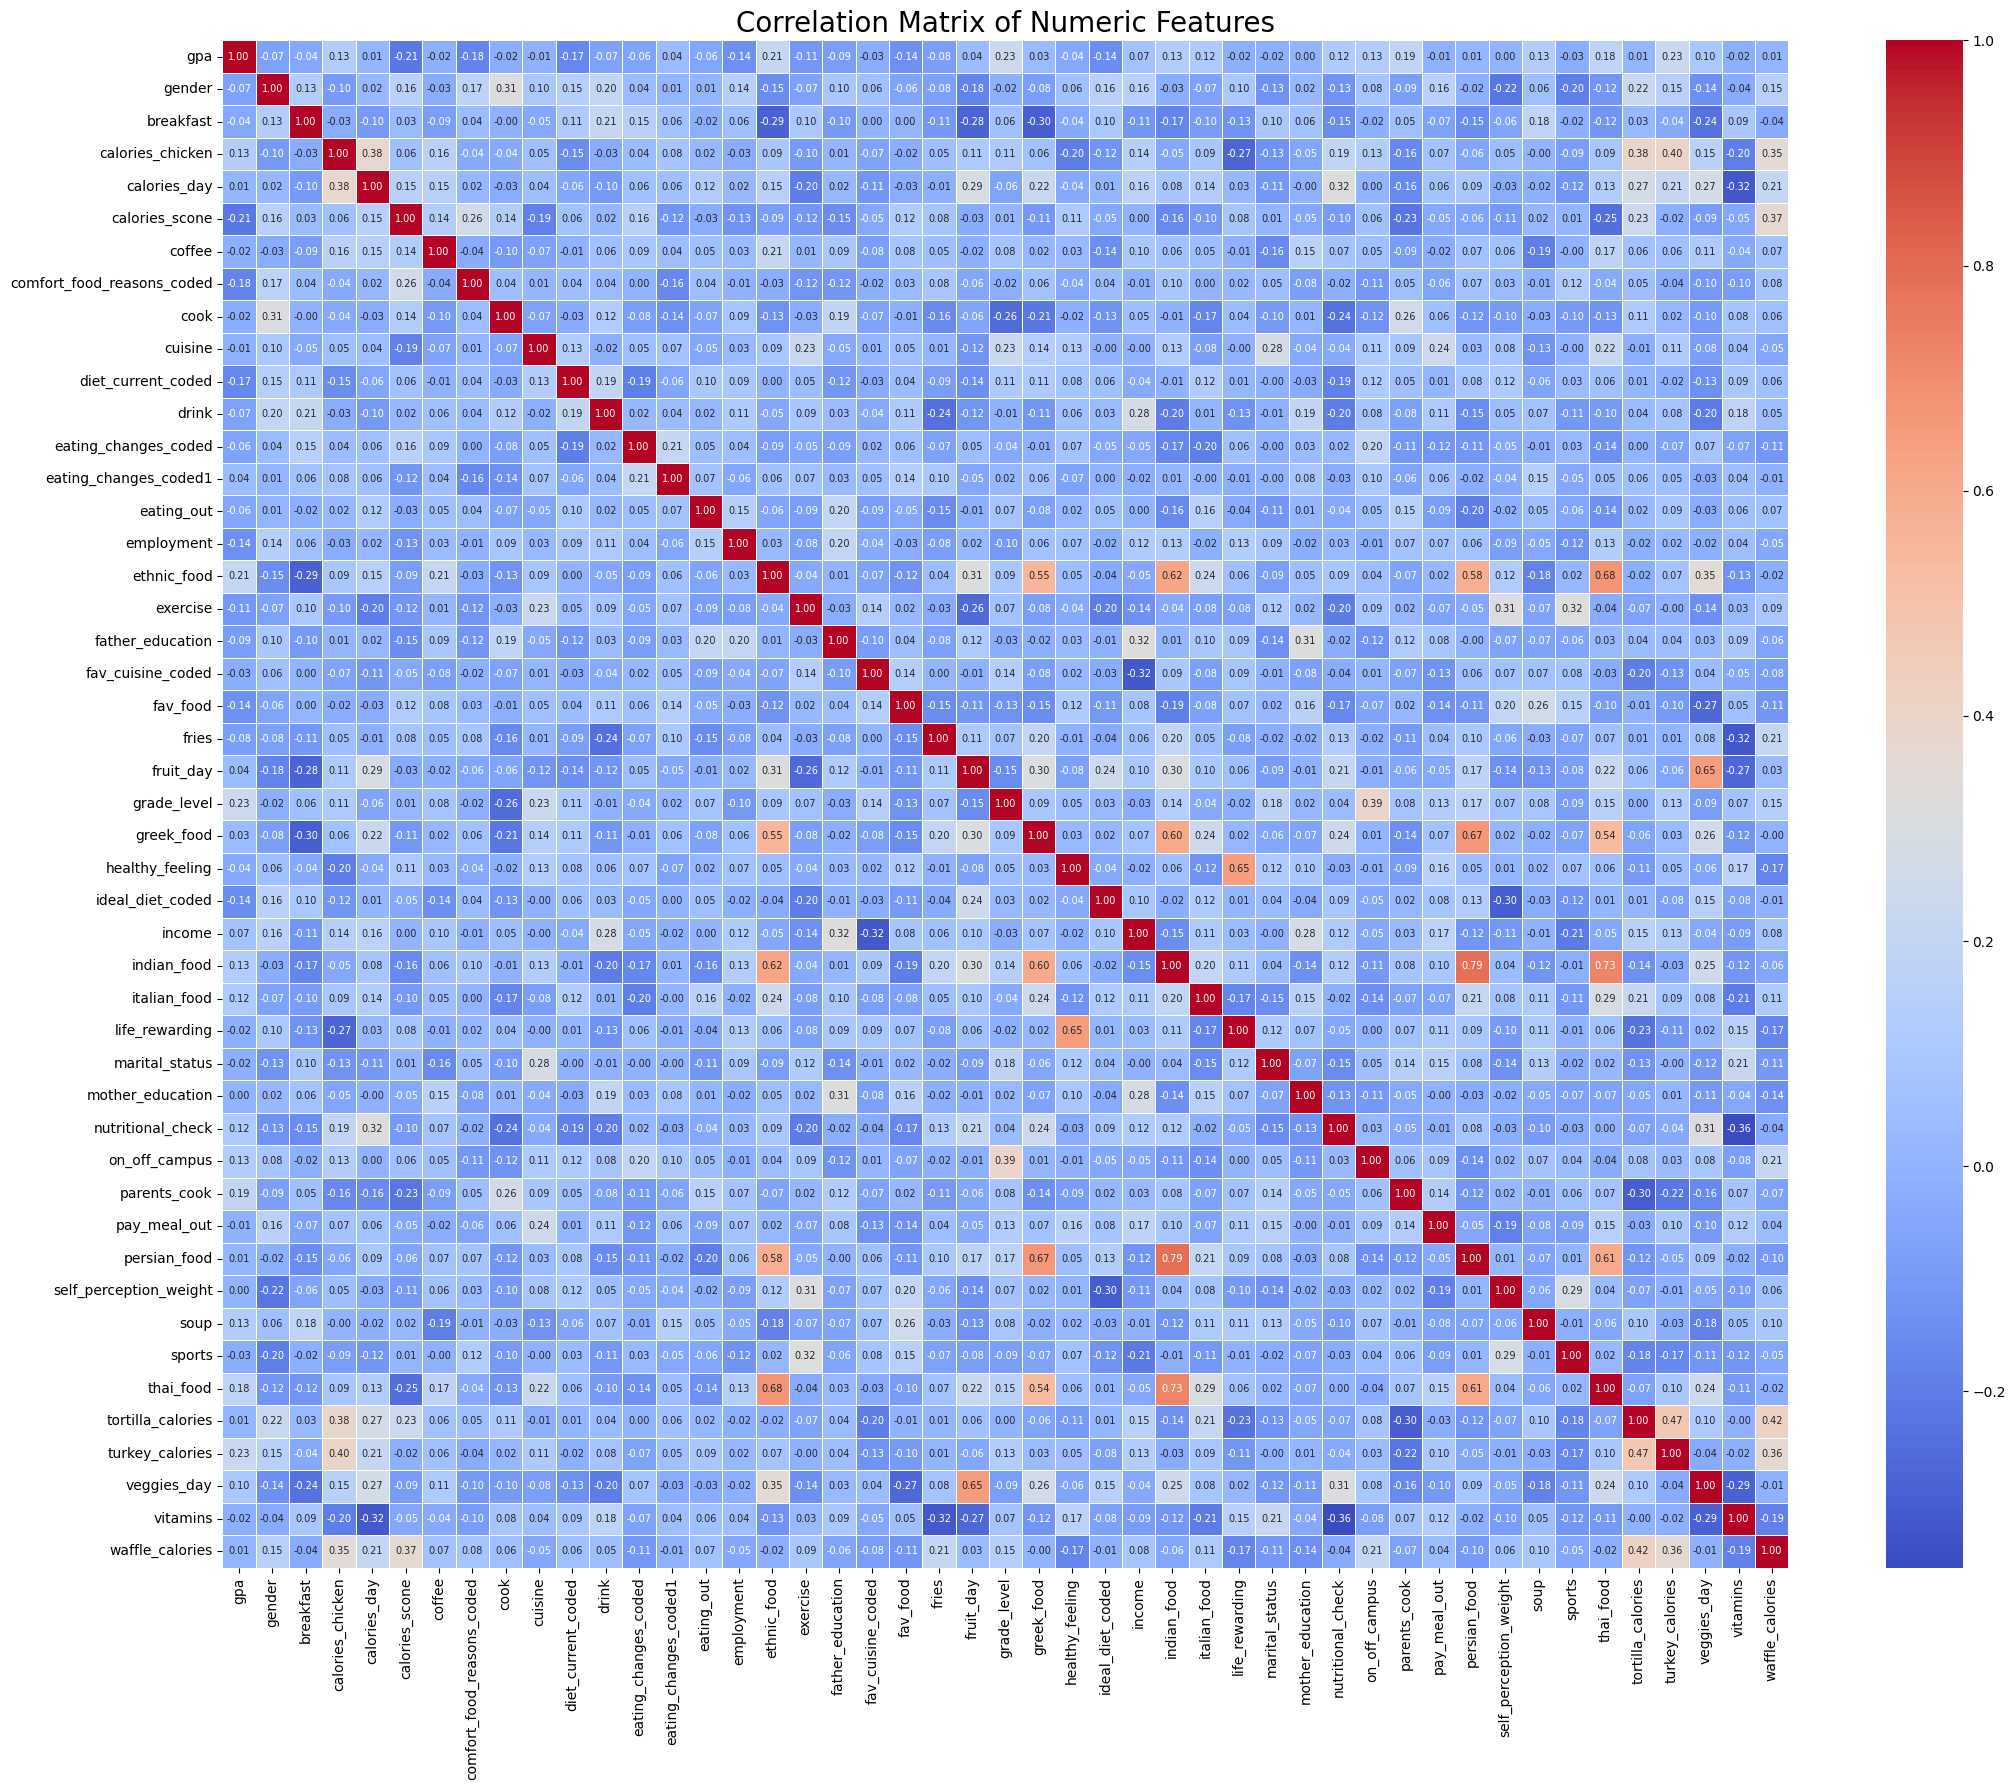

In [ ]:
numeric_df = df_cleaned.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(22, 18))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Matrix of Numeric Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Flag highly correlated pairs (> 0.95)
high_corr_threshold = 0.95
highly_correlated_pairs = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > high_corr_threshold:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            highly_correlated_pairs.add(tuple(sorted((col1, col2))))

if highly_correlated_pairs:
    print("Highly correlated pairs (> 0.95):")
    for pair in highly_correlated_pairs:
        print(f"  {pair[0]}  ↔  {pair[1]}  ({correlation_matrix.loc[pair[0], pair[1]]:.2f})")
else:
    print("No highly correlated pairs found.")

No highly correlated pairs found.


## 4. Feature Engineering & Encoding

In [ ]:
# One-hot encode remaining object columns
object_cols_cleaned = df_cleaned.select_dtypes(include='object').columns.tolist()
print(f"Object columns to encode: {object_cols_cleaned}")

df_encoded = pd.get_dummies(df_cleaned, columns=object_cols_cleaned, drop_first=False)
print(f"Shape after one-hot encoding: {df_encoded.shape}")
df_encoded.info()

Object columns to encode: ['comfort_food', 'father_profession', 'food_childhood', 'healthy_meal', 'meals_dinner_friend', 'mother_profession', 'type_sports', 'weight']
Shape after one-hot encoding: (125, 869)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Columns: 869 entries, gpa to weight_Not sure, 240
dtypes: bool(822), float64(21), int64(26)
memory usage: 146.4 KB


## 5. Gender Classification Model

In [ ]:
# Define features and target
if 'gender' in df_encoded.columns:
    X = df_encoded.drop('gender', axis=1)
    y = df_encoded['gender']
    print(f"X shape: {X.shape}, y shape: {y.shape}")
else:
    raise ValueError("'gender' column not found — check encoding step")

X shape: (125, 868), y shape: (125,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (100, 868) | Test: (25, 868)


In [ ]:
# --- Logistic Regression with GridSearchCV ---
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
param_grid    = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search   = GridSearchCV(log_reg_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_
print(f"Best C: {grid_search.best_params_['C']}")

Best C: 0.1


In [ ]:
# --- Evaluate Logistic Regression ---
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print("=== Training Set ===")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(classification_report(y_train, y_train_pred))

print("\n=== Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(classification_report(y_test, y_test_pred))

=== Training Set ===
Accuracy: 0.9300
              precision    recall  f1-score   support

           1       0.92      0.97      0.94        61
           2       0.94      0.87      0.91        39

    accuracy                           0.93       100
   macro avg       0.93      0.92      0.93       100
weighted avg       0.93      0.93      0.93       100


=== Test Set ===
Accuracy: 0.6400
              precision    recall  f1-score   support

           1       0.67      0.80      0.73        15
           2       0.57      0.40      0.47        10

    accuracy                           0.64        25
   macro avg       0.62      0.60      0.60        25
weighted avg       0.63      0.64      0.62        25



In [ ]:
# --- Random Forest for comparison ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_rf_pred = rf_model.predict(X_test)
print("=== Random Forest — Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_rf_pred):.4f}")
print(classification_report(y_test, y_rf_pred))

print(f"\nLogistic Regression Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Random Forest Test Accuracy:       {accuracy_score(y_test, y_rf_pred):.4f}")

=== Random Forest — Test Set ===
Accuracy: 0.6800
              precision    recall  f1-score   support

           1       0.65      1.00      0.79        15
           2       1.00      0.20      0.33        10

    accuracy                           0.68        25
   macro avg       0.83      0.60      0.56        25
weighted avg       0.79      0.68      0.61        25


Logistic Regression Test Accuracy: 0.6400
Random Forest Test Accuracy:       0.6800


## 6. Weight Category Prediction Model (with PCA)

In [ ]:
# --- Prepare weight target ---
print("Unique values in 'weight' before processing:")
print(df_cleaned['weight'].value_counts())

df_cleaned = df_cleaned.copy()  # avoid SettingWithCopyWarning
df_cleaned['weight_numeric'] = pd.to_numeric(df_cleaned['weight'], errors='coerce')

bins   = [0, 140, 170, float('inf')]
labels = ['Low Weight', 'Medium Weight', 'High Weight']
df_cleaned['weight_category'] = pd.cut(
    df_cleaned['weight_numeric'], bins=bins, labels=labels, right=False
)

print("\nWeight category distribution:")
print(df_cleaned['weight_category'].value_counts())

Unique values in 'weight' before processing:
weight
135    10
140     8
170     7
150     7
185     6
       ..
260     1
184     1
230     1
138     1
156     1
Name: count, Length: 47, dtype: int64

Weight category distribution:
weight_category
High Weight      45
Low Weight       39
Medium Weight    38
Name: count, dtype: int64


In [ ]:
# --- Build feature matrix for weight prediction ---
X_features = df_cleaned.drop(columns=['weight', 'weight_numeric', 'weight_category'])

obj_cols_weight = X_features.select_dtypes(include='object').columns.tolist()
X_weight_encoded = pd.get_dummies(X_features, columns=obj_cols_weight, drop_first=False)

y_weight = df_cleaned['weight_category']

# Drop rows where weight couldn't be parsed
valid_idx = y_weight.dropna().index
X_weight_encoded = X_weight_encoded.loc[valid_idx]
y_weight = y_weight.loc[valid_idx]

print(f"X shape: {X_weight_encoded.shape}, y shape: {y_weight.shape}")

X shape: (122, 822), y shape: (122,)


In [ ]:
# --- Train-test split (filter single-sample classes) ---
class_counts = y_weight.value_counts()
single_sample_classes = class_counts[class_counts == 1].index
mask = ~y_weight.isin(single_sample_classes)

X_w = X_weight_encoded[mask]
y_w = y_weight[mask]

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w, y_w, test_size=0.25, random_state=42, stratify=y_w
)
print(f"Train: {X_train_w.shape} | Test: {X_test_w.shape}")

Train: (91, 822) | Test: (31, 822)


In [ ]:
# --- Logistic Regression baseline for weight ---
lr_w = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
gs_w = GridSearchCV(lr_w, {'C': [0.001, 0.01, 0.1, 1, 10, 100]}, cv=5, scoring='accuracy', n_jobs=-1)
gs_w.fit(X_train_w, y_train_w)
model_w = gs_w.best_estimator_
print(f"Best C: {gs_w.best_params_['C']}")

print("\n=== Weight Model — Test Set ===")
y_pred_w = model_w.predict(X_test_w)
print(f"Accuracy: {accuracy_score(y_test_w, y_pred_w):.4f}")
print(classification_report(y_test_w, y_pred_w))

Best C: 0.1

=== Weight Model — Test Set ===
Accuracy: 0.4516
               precision    recall  f1-score   support

  High Weight       0.40      0.55      0.46        11
   Low Weight       0.50      0.40      0.44        10
Medium Weight       0.50      0.40      0.44        10

     accuracy                           0.45        31
    macro avg       0.47      0.45      0.45        31
 weighted avg       0.46      0.45      0.45        31



In [ ]:
# --- PCA to combat overfitting (823 features, ~120 samples) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_w)
X_test_sc  = scaler.transform(X_test_w)

pca = PCA(n_components=0.95)  # keep 95% of variance
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f"Original features : {X_train_w.shape[1]}")
print(f"After PCA         : {X_train_pca.shape[1]}")
print(f"Variance retained : {pca.explained_variance_ratio_.sum():.2f}")

Original features : 822
After PCA         : 84
Variance retained : 0.96


In [ ]:
# --- Logistic Regression on PCA features ---
lr_pca = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
gs_pca = GridSearchCV(lr_pca, {'C': [0.001, 0.01, 0.1, 1, 10, 100]}, cv=5, scoring='accuracy', n_jobs=-1)
gs_pca.fit(X_train_pca, y_train_w)
model_pca = gs_pca.best_estimator_
print(f"Best C (PCA model): {gs_pca.best_params_['C']}")

y_train_pred_pca = model_pca.predict(X_train_pca)
y_test_pred_pca  = model_pca.predict(X_test_pca)

print("\n=== PCA + LR — Training Set ===")
print(f"Accuracy: {accuracy_score(y_train_w, y_train_pred_pca):.4f}")
print(classification_report(y_train_w, y_train_pred_pca))

print("\n=== PCA + LR — Test Set ===")
print(f"Accuracy: {accuracy_score(y_test_w, y_test_pred_pca):.4f}")
print(classification_report(y_test_w, y_test_pred_pca))

Best C (PCA model): 0.001

=== PCA + LR — Training Set ===
Accuracy: 0.9670
               precision    recall  f1-score   support

  High Weight       0.97      0.97      0.97        34
   Low Weight       0.93      0.97      0.95        29
Medium Weight       1.00      0.96      0.98        28

     accuracy                           0.97        91
    macro avg       0.97      0.97      0.97        91
 weighted avg       0.97      0.97      0.97        91


=== PCA + LR — Test Set ===
Accuracy: 0.4194
               precision    recall  f1-score   support

  High Weight       0.47      0.64      0.54        11
   Low Weight       0.57      0.40      0.47        10
Medium Weight       0.22      0.20      0.21        10

     accuracy                           0.42        31
    macro avg       0.42      0.41      0.41        31
 weighted avg       0.42      0.42      0.41        31



---
## 7. 🆕 Interactive Weight Predictor

This section trains a lightweight Random Forest on a small set of key features and then **asks YOU questions** to predict your weight range.

Key features chosen based on correlation analysis and domain knowledge:
- Gender, exercise habits, GPA, calorie awareness, eating-out frequency, healthy meal frequency, sport participation.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Build a lightweight predictor on interpretable features only
# ─────────────────────────────────────────────────────────────────────────────

PREDICTOR_FEATURES = [
    'gender',
    'exercise',
    'calories_day',
    'healthy_meal',
    'eating_out',
    'fav_food',
    'sports',
    'gpa'
]

# Filter to features that actually exist in df_cleaned
available_features = [f for f in PREDICTOR_FEATURES if f in df_cleaned.columns]
print(f"Using features: {available_features}")

X_pred = df_cleaned[available_features].copy()

# Ensure all numeric
for col in X_pred.columns:
    X_pred[col] = pd.to_numeric(X_pred[col], errors='coerce')
    X_pred[col] = X_pred[col].fillna(X_pred[col].median())

y_pred_target = df_cleaned['weight_category'].copy()

# Align valid rows
valid = y_pred_target.dropna().index
X_pred = X_pred.loc[valid]
y_pred_target = y_pred_target.loc[valid]

# Train Random Forest on all available data (we'll use it for live predictions)
rf_predictor = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_predictor.fit(X_pred, y_pred_target)

# Quick CV accuracy
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf_predictor, X_pred, y_pred_target, cv=5, scoring='accuracy')
print(f"Cross-validated accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

Using features: ['gender', 'exercise', 'calories_day', 'healthy_meal', 'eating_out', 'fav_food', 'sports', 'gpa']
Cross-validated accuracy: 0.47 ± 0.10


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: ask a question and validate input
# ─────────────────────────────────────────────────────────────────────────────

def ask(question, options: dict, default=None):
    """
    Print a question with numbered options and return the coded value.
    options = {display_label: numeric_code}
    """
    print(f"\n{'─'*55}")
    print(f"  {question}")
    items = list(options.items())
    for i, (label, _) in enumerate(items, 1):
        print(f"    [{i}] {label}")

    while True:
        raw = input("  Your answer (enter number): ").strip()
        if raw == '' and default is not None:
            return default
        if raw.isdigit() and 1 <= int(raw) <= len(items):
            label, code = items[int(raw) - 1]
            print(f"  ✔ {label}")
            return code
        print(f"  ⚠ Please enter a number between 1 and {len(items)}.")


def ask_float(question, lo, hi, default=None):
    """Ask for a numeric value within [lo, hi]."""
    print(f"\n{'─'*55}")
    print(f"  {question}")
    while True:
        raw = input(f"  Enter a value between {lo} and {hi}: ").strip()
        if raw == '' and default is not None:
            return default
        try:
            val = float(raw)
            if lo <= val <= hi:
                return val
        except ValueError:
            pass
        print(f"  ⚠ Please enter a number between {lo} and {hi}.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Interactive Weight Predictor
# ─────────────────────────────────────────────────────────────────────────────

def predict_weight():
    print("\n" + "═"*55)
    print("  🏋️  WEIGHT RANGE PREDICTOR  🏋️")
    print("  Answer a few quick questions about your lifestyle.")
    print("  We'll predict whether your weight is likely Low,")
    print("  Medium, or High based on eating & fitness habits.")
    print("═"*55)

    answers = {}

    # --- Gender ---
    if 'gender' in available_features:
        answers['gender'] = ask(
            "What is your gender?",
            {
                "Male"   : 1,
                "Female" : 2
            }
        )

    # --- Exercise frequency ---
    if 'exercise' in available_features:
        answers['exercise'] = ask(
            "How often do you exercise?",
            {
                "Everyday"                : 1,
                "Twice or three per week" : 2,
                "Once a week"             : 3,
                "Sometimes"               : 4,
                "Never"                   : 5
            }
        )

    # --- Calories awareness ---
    if 'calories_day' in available_features:
        answers['calories_day'] = ask(
            "How many calories do you think you eat per day?",
            {
                "Less than 1500 kcal"   : 1,
                "1500 – 2000 kcal"      : 2,
                "2000 – 2500 kcal"      : 3,
                "More than 2500 kcal"   : 4,
                "Not sure"              : 5
            }
        )

    # --- Healthy meal frequency ---
    if 'healthy_meal' in available_features:
        answers['healthy_meal'] = ask(
            "How often do you eat a healthy home-cooked meal?",
            {
                "Every day"   : 1,
                "3–5 days/week" : 2,
                "1–2 days/week" : 3,
                "Rarely"      : 4,
                "Never"       : 5
            }
        )

    # --- Eating out frequency ---
    if 'eating_out' in available_features:
        answers['eating_out'] = ask(
            "How often do you eat out / order takeaway per week?",
            {
                "Never"            : 1,
                "1–2 times"        : 2,
                "2–3 times"        : 3,
                "3–5 times"        : 4,
                "Almost every meal": 5
            }
        )

    # --- Favourite food category ---
    if 'fav_food' in available_features:
        answers['fav_food'] = ask(
            "Which best describes your favourite food type?",
            {
                "Home food (cooked)"       : 1,
                "Fast food / junk"         : 2,
                "Italian / American style" : 3,
                "Healthy / clean eating"   : 4
            }
        )

    # --- Sports participation ---
    if 'sports' in available_features:
        answers['sports'] = ask(
            "Do you play a sport or do organised physical activity?",
            {
                "Yes, regularly" : 1,
                "Occasionally"   : 1,   # map to same as yes
                "No"             : 2
            }
        )

    # --- GPA ---
    if 'gpa' in available_features:
        answers['gpa'] = ask_float(
            "What is your approximate GPA (or academic score 0.0 – 4.0)?",
            lo=0.0, hi=4.0, default=3.0
        )

    # --- Build input row in the correct feature order ---
    input_row = pd.DataFrame(
        [[answers.get(f, X_pred[f].median()) for f in available_features]],
        columns=available_features
    )

    # --- Predict ---
    prediction   = rf_predictor.predict(input_row)[0]
    probabilities = rf_predictor.predict_proba(input_row)[0]
    classes      = rf_predictor.classes_

    # --- Display results ---
    print("\n" + "═"*55)
    print("  📊  PREDICTION RESULTS")
    print("═"*55)

    emoji_map = {
        'Low Weight'    : '🟢',
        'Medium Weight' : '🟡',
        'High Weight'   : '🔴'
    }

    print(f"\n  Predicted weight range:  {emoji_map.get(str(prediction), '⚪')} {prediction}")
    print("\n  Confidence breakdown:")
    for cls, prob in sorted(zip(classes, probabilities), key=lambda x: -x[1]):
        bar = '█' * int(prob * 20)
        print(f"    {emoji_map.get(str(cls), '⚪')} {str(cls):<16} {bar:<20} {prob*100:.1f}%")

    weight_ranges = {
        'Low Weight'    : 'under ~140 lbs  / ~64 kg',
        'Medium Weight' : '140–170 lbs     / 64–77 kg',
        'High Weight'   : 'above 170 lbs   / ~77 kg+'
    }
    print(f"\n  Reference range  → {weight_ranges.get(str(prediction), '')}")
    print("\n  ⚠️  This is a statistical estimate based on food &")
    print("     lifestyle patterns — not a medical assessment.")
    print("═"*55)

    return prediction, dict(zip(classes, probabilities))


# ── Run the predictor ──
result = predict_weight()


═══════════════════════════════════════════════════════
  🏋️  WEIGHT RANGE PREDICTOR  🏋️
  Answer a few quick questions about your lifestyle.
  We'll predict whether your weight is likely Low,
  Medium, or High based on eating & fitness habits.
═══════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  What is your gender?
    [1] Male
    [2] Female
  Your answer (enter number): 1
  ✔ Male

───────────────────────────────────────────────────────
  How often do you exercise?
    [1] Everyday
    [2] Twice or three per week
    [3] Once a week
    [4] Sometimes
    [5] Never
  Your answer (enter number): 2
  ✔ Twice or three per week

───────────────────────────────────────────────────────
  How many calories do you think you eat per day?
    [1] Less than 1500 kcal
    [2] 1500 – 2000 kcal
    [3] 2000 – 2500 kcal
    [4] More than 2500 kcal
    [5] Not sure
  Your answer (enter number): 3
  ✔ 2000 – 2500 kcal

──────────────────

In [ ]:
df.isnull().sum()

,0
gpa,0
gender,0
breakfast,0
calories_chicken,0
calories_day,0
...,...
type_sports,0
veggies_day,0
vitamins,0
waffle_calories,0
